In [ ]:
import fiftyone as fo 
import fiftyone.brain as fob
from fiftyone import ViewField as F 
import os



In [9]:
from anomalib.data import Folder
from anomalib.models import Padim
from anomalib.engine import Engine
import torch

def train_socket_inspector():
    # 1. Initialize Data Module
    # We point it to the folder we created in Script 1
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins",
        normal_dir="train/good",  # Folder name for good images
        abnormal_dir= None # Folder name for defects (get some)
    )
    
    # 2. Initialize Model (PaDiM)
    # ResNet18 is the standard backbone, lightweight and effective
    model = Padim(backbone="resnet18")
    
    # 3. Training Engine
    # 'image_metrics' gives you an AUROC score to judge accuracy
    engine = Engine()
    
    # 4. Fit the model
    print("Starting training...")
    engine.fit(datamodule=datamodule, model=model)
    
    # 5. Test (Optional, if you have a test set)
    engine.test(datamodule=datamodule, model=model)
    print("Training complete. Model saved.")

    engine.export(
        model=model,
        export_type="torch", # or "openvino" for Intel optimization
        ckpt_path="results/Padim/socket_pins/latest/weights/lightning/model.ckpt",
    )
    print("Model exported to .pt format successfully.")

if __name__ == "__main__":
    train_socket_inspector()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training...


c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

...

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\torchmetrics\utilities\prints.py:43: 
UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in 
true positive score
  warnings.warn(*args, **kwargs)

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\torchmetrics\utilities\prints.py:43: 
UserWarning: The ``compute`` method of metric AUROC was called before the ``update`` method which may lead to 
errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\torchmetrics\utilities\prints.py:43: 
UserWarning: The ``compute`` method of metric F1Score was called before the ``update`` method which may lead to 
errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            0.0            │
│       image_F1Score       │            0.0            │
└───────────────────────────┴───────────────────────────┘

Training complete. Model saved.
Model exported to .pt format successfully.


WARNING:anomalib.deploy.inferencers.torch_inferencer:TorchInferencer is a legacy inferencer. Consider using 
Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.

WARNING:anomalib.deploy.inferencers.torch_inferencer:TRUST_REMOTE_CODE is set to True. Loading model using pickle 
module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST 
the source of the checkpoint.

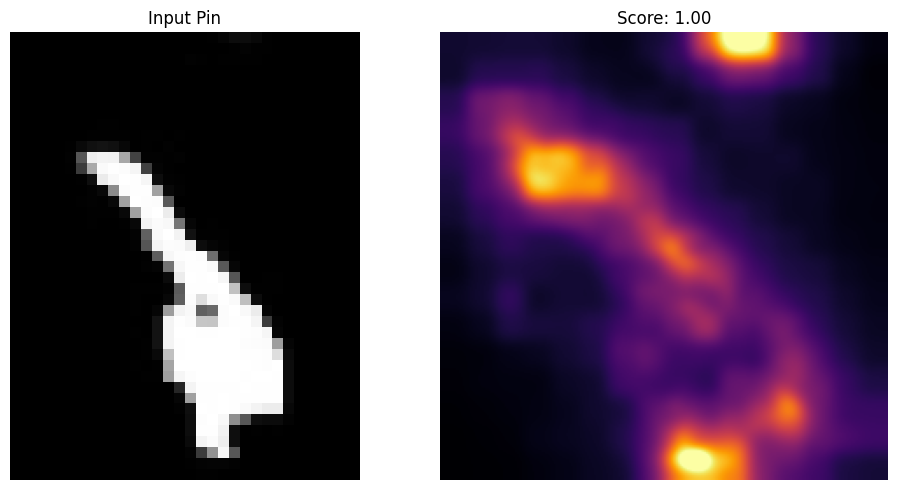

WARNING:anomalib.deploy.inferencers.torch_inferencer:TorchInferencer is a legacy inferencer. Consider using 
Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.

WARNING:anomalib.deploy.inferencers.torch_inferencer:TRUST_REMOTE_CODE is set to True. Loading model using pickle 
module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST 
the source of the checkpoint.

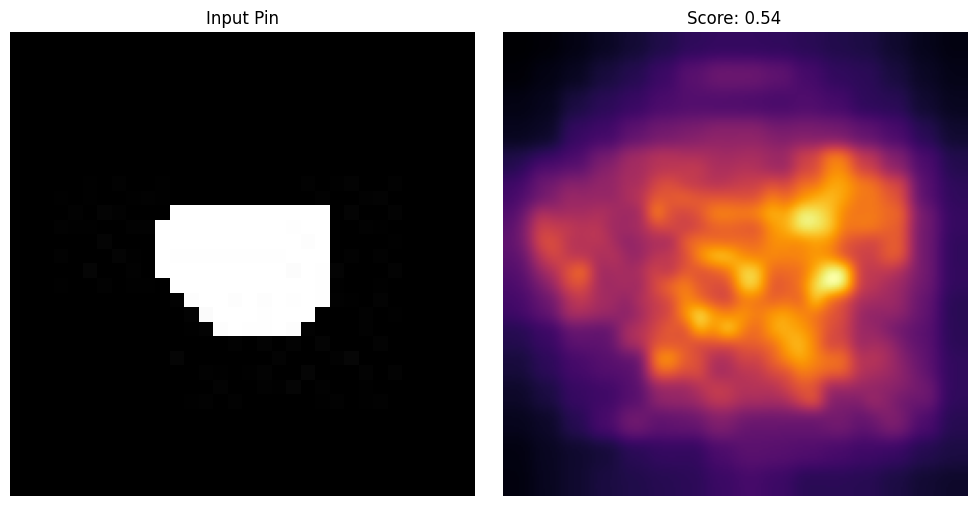

In [10]:
from anomalib.deploy import TorchInferencer
import cv2
import matplotlib.pyplot as plt
import dotenv

dotenv.load_dotenv()

def inspect_pin(model_path, pin_image_path):
    # 1. Load Model
    inferencer = TorchInferencer(path=model_path, device="cpu")
    
    # 2. Predict
    predictions = inferencer.predict(image=pin_image_path)
    
    # --- FIX 1: HANDLE HEATMAP SHAPE ---
    anom_map = predictions.anomaly_map
    if hasattr(anom_map, "cpu"): 
        anom_map = anom_map.cpu().numpy()
    anom_map = anom_map.squeeze() # Removes (1, 256, 256) -> (256, 256)

    # --- FIX 2: HANDLE SCORE FORMATTING ---
    # Convert Tensor to float using .item()
    score = predictions.pred_score.item() 

    # 3. Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original Image
    ax[0].imshow(cv2.cvtColor(cv2.imread(pin_image_path), cv2.COLOR_BGR2RGB))
    ax[0].set_title("Input Pin")
    ax[0].axis('off')
    
    # Anomaly Heatmap
    ax[1].imshow(anom_map, cmap='inferno') 
    ax[1].set_title(f"Score: {score:.2f}") # Now valid because 'score' is a float
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

img = "datasets/socket_pins/test/defect/image.png"
inspect_pin("results/Padim/socket_pins/latest/weights/torch/model.pt", img)
img = "datasets/socket_pins/test/good/pin_5.png"
inspect_pin("results/Padim/socket_pins/latest/weights/torch/model.pt", img)